# **👗 Women's Clothing Sales Predictor**

**Predicting `units_sold` for women's fashion products using product & pricing features.**

This notebook follows a clean, beginner-friendly ML workflow:
1. Load & explore the data
2. Check data quality (missing values, duplicates, **data leakage**)
3. Feature engineering & preprocessing
4. Train & compare 3 models: Random Forest, XGBoost, LightGBM
5. Evaluate honestly (no inflated scores)
6. Conclusion & key takeaways

**Dataset:** 50,000 women's clothing products with price, category, material, ratings, and sales data.


## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## **2. Load the Dataset**

We're loading 50,000 rows of women's clothing product data. Let's take a first look.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/razanihababdellatif/womens-e-commerce-clothing-reviews-and-sales/women_clothing_50k.csv')
print("Shape:", df.shape)
df.head()


Shape: (50000, 15)


,product_id,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
0,WC000001,Jeans,Skinny Jeans,Denim,Red,M,Summer,Business Casual,37.00,0,0.0,0,2,14,0.17
1,WC000002,Dresses,Wrap Dress,Cotton,White,M,Winter,Casual,59.12,10,0.0,0,13,31,0.13
2,WC000003,T-Shirts,V-Neck T-Shirt,Cotton,Purple,M,All Season,Casual,27.65,0,0.0,0,10,2,0.11
3,WC000004,Sweaters,Oversized Sweater,Wool,Brown,S,Winter,Formal,72.64,0,2.9,17,104,292,0.14
4,WC000005,Sweaters,Oversized Sweater,Wool,White,M,Winter,Minimalist,72.61,40,0.0,0,12,15,0.07


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        50000 non-null  object 
 1   category          50000 non-null  object 
 2   subcategory       50000 non-null  object 
 3   material          50000 non-null  object 
 4   color             50000 non-null  object 
 5   size              50000 non-null  object 
 6   season            50000 non-null  object 
 7   style             50000 non-null  object 
 8   price_usd         50000 non-null  float64
 9   discount_percent  50000 non-null  int64  
 10  rating            50000 non-null  float64
 11  review_count      50000 non-null  int64  
 12  stock_quantity    50000 non-null  int64  
 13  units_sold        50000 non-null  int64  
 14  return_rate       50000 non-null  float64
dtypes: float64(3), int64(4), object(8)
memory usage: 5.7+ MB


## **3. Data Quality Checks**

Before building any model, we always check for:
- Missing values
- Duplicate rows
- Weird/invalid values
- **Data leakage** — features that "give away" the answer

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Duplicate product_id:", df['product_id'].duplicated().sum())


Missing values per column:
product_id          0
category            0
subcategory         0
material            0
color               0
size                0
season              0
style               0
price_usd           0
discount_percent    0
rating              0
review_count        0
stock_quantity      0
units_sold          0
return_rate         0
dtype: int64

Duplicate rows: 0

Duplicate product_id: 0


In [5]:
df.describe()


,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,61.858053,9.617800,3.056088,9.767320,37.515080,185.190660,0.107761
std,36.067137,12.369801,1.905743,32.783376,39.945939,530.180836,0.031606
min,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.890000,0.000000,0.000000,0.000000,9.000000,21.000000,0.080000
50%,53.750000,0.000000,3.900000,2.000000,25.000000,59.000000,0.110000
75%,80.030000,15.000000,4.400000,8.000000,53.000000,163.000000,0.130000
max,275.560000,50.000000,5.000000,1639.000000,531.000000,31215.000000,0.230000


### **🔎 Data Leakage Check**

Our target column is **`units_sold`** (how many units of a product were sold).

Let's check correlation of all numeric columns with `units_sold` to spot any column
that is *too* correlated — that usually means it was computed **from** the target
itself, which would be data leakage.

In [6]:
corr = df.corr(numeric_only=True)['units_sold'].sort_values(ascending=False)
print(corr)


units_sold          1.000000
review_count        0.901413
rating              0.188214
discount_percent    0.044819
return_rate         0.022652
price_usd           0.001751
stock_quantity      0.001024
Name: units_sold, dtype: float64


**Finding:** `review_count` has a **0.90 correlation** with `units_sold`.

This makes sense in real life — the more units sold, the more reviews a product
naturally accumulates — but that also means `review_count` is essentially a
**proxy for the target itself**. If we let the model use it, it would get an
unrealistically high score by "cheating," not by learning real sales drivers.

👉 **We will drop `review_count` from our features to avoid data leakage.**
We'll keep `rating`, since a rating (1–5 stars) doesn't directly encode sales volume.
`product_id` is just an identifier and will also be dropped.

**## **4. Quick Exploratory Data Analysis

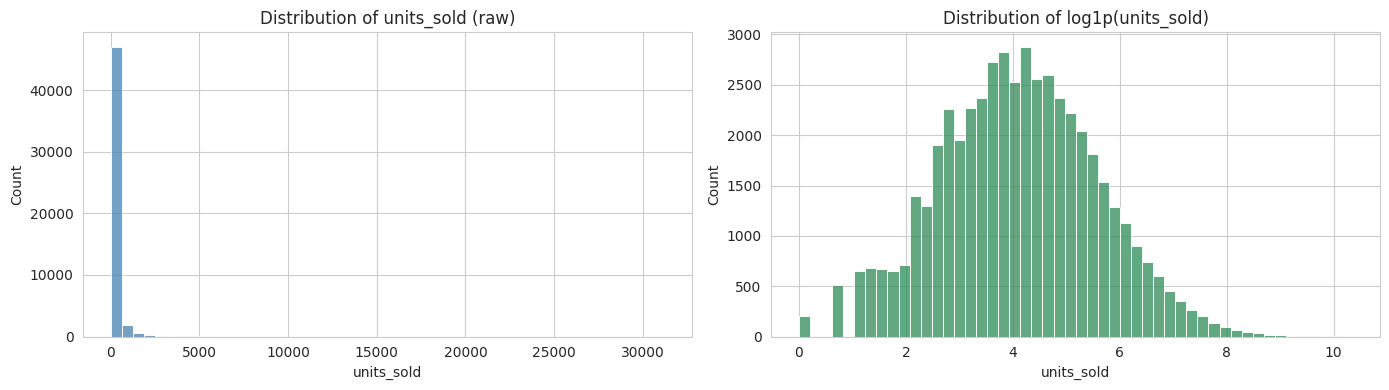

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['units_sold'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of units_sold (raw)')

sns.histplot(np.log1p(df['units_sold']), bins=50, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of log1p(units_sold)')

plt.tight_layout()
plt.show()


`units_sold` is heavily right-skewed (a few products sell a LOT).
We'll predict **`log1p(units_sold)`** instead of the raw value — this is a standard
trick that helps regression models learn much better on skewed targets.

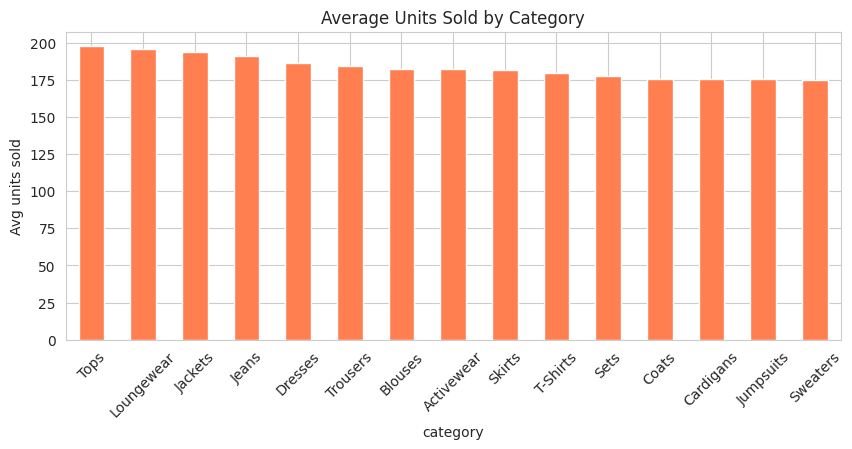

In [8]:
plt.figure(figsize=(10,4))
df.groupby('category')['units_sold'].mean().sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title('Average Units Sold by Category')
plt.ylabel('Avg units sold')
plt.xticks(rotation=45)
plt.show()


## **5. Feature Engineering & Preprocessing**

- Drop `product_id` (identifier) and `review_count` (data leakage)
- Log-transform the target `units_sold`
- Label-encode categorical columns (simple & beginner-friendly approach)

In [9]:
target_raw = df['units_sold']
y = np.log1p(target_raw)          # log-transformed target

X = df.drop(columns=['product_id', 'units_sold', 'review_count'])

cat_cols = ['category', 'subcategory', 'material', 'color', 'size', 'season', 'style']
num_cols = ['price_usd', 'discount_percent', 'rating', 'stock_quantity', 'return_rate']

# Label encode categorical columns
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c])
    encoders[c] = le

print("Final feature set:", X.columns.tolist())
X.head()


Final feature set: ['category', 'subcategory', 'material', 'color', 'size', 'season', 'style', 'price_usd', 'discount_percent', 'rating', 'stock_quantity', 'return_rate']


,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,stock_quantity,return_rate
0,6,36,2,9,1,3,1,37.00,0,0.0,2,0.17
1,4,54,0,10,1,4,2,59.12,10,0.0,13,0.13
2,12,49,0,8,1,0,2,27.65,0,0.0,10,0.11
3,11,30,9,3,2,4,4,72.64,0,2.9,104,0.14
4,11,30,9,10,1,4,5,72.61,40,0.0,12,0.07


## **6. Train / Test Split**

We split 80% for training and 20% for testing. The test set is never seen during
training — it's our honest, unbiased check of model performance.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (40000, 12)
Test size: (10000, 12)


## **7. Model Training — Comparing 3 Models**

We'll train and compare three popular tree-based models:
- **Random Forest** — a solid, reliable baseline
- **XGBoost** — often a top performer on tabular data
- **LightGBM** — fast and efficient, great for larger datasets

**A note on evaluation (being honest about metrics):** `units_sold` has extreme
outliers (some products sell 100x more than average). If we measure R² on the
*raw* sales numbers, a handful of outliers dominate the score and make it look
almost meaningless. Since we trained on `log1p(units_sold)`, we evaluate
**R² and RMSE in the log scale** (our real training objective) as the primary,
honest metric — and we also decode predictions back to real units to report
an interpretable MAE in "units sold."


In [11]:
results = {}

def evaluate(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds_log = model.predict(X_test)

    # Primary, honest metrics: computed in the same log-scale we trained on
    r2_log = r2_score(y_test, preds_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, preds_log))

    # Secondary, interpretable metric: decode back to real "units sold"
    preds = np.clip(np.expm1(preds_log), 0, None)
    actual = np.expm1(y_test)
    mae_units = mean_absolute_error(actual, preds)

    results[name] = {'R2 (log)': r2_log, 'RMSE (log)': rmse_log, 'MAE (units)': mae_units}
    print(f"{name:15s} | R2(log): {r2_log:.4f} | RMSE(log): {rmse_log:.4f} | MAE(units): {mae_units:7.2f}")
    return model


In [12]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf = evaluate("Random Forest", rf, X_train, y_train, X_test, y_test)


Random Forest   | R2(log): 0.4855 | RMSE(log): 1.0701 | MAE(units):  153.16


In [13]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_model = evaluate("XGBoost", xgb_model, X_train, y_train, X_test, y_test)


XGBoost         | R2(log): 0.4793 | RMSE(log): 1.0766 | MAE(units):  153.55


In [14]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
lgb_model = evaluate("LightGBM", lgb_model, X_train, y_train, X_test, y_test)


LightGBM        | R2(log): 0.4821 | RMSE(log): 1.0737 | MAE(units):  153.43


## **8. Model Comparison**

               R2 (log)  RMSE (log)  MAE (units)
Random Forest  0.485545    1.070102   153.157061
LightGBM       0.482117    1.073662   153.434123
XGBoost        0.479302    1.076576   153.553296


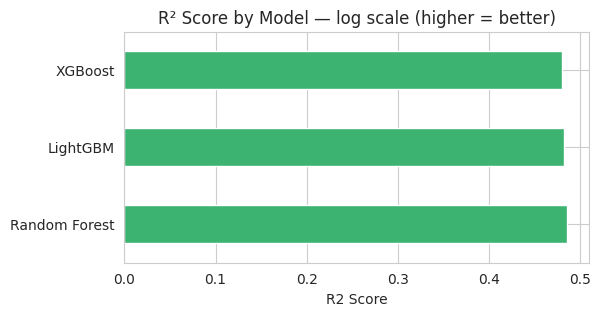

In [15]:
results_df = pd.DataFrame(results).T.sort_values('R2 (log)', ascending=False)
print(results_df)

results_df['R2 (log)'].plot(kind='barh', figsize=(6,3), color='mediumseagreen')
plt.title('R² Score by Model — log scale (higher = better)')
plt.xlabel('R2 Score')
plt.show()


## **9. Feature Importance (Best Model)**

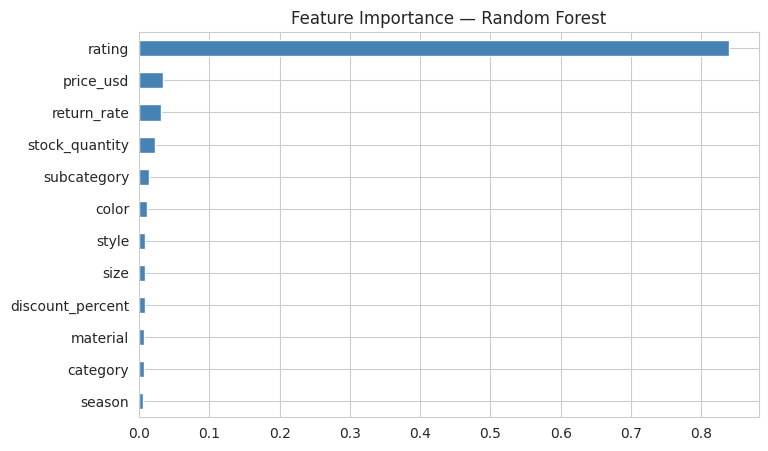

rating              0.839920
price_usd           0.034106
return_rate         0.031352
stock_quantity      0.023032
subcategory         0.014697
color               0.011685
style               0.008216
size                0.008213
discount_percent    0.007926
material            0.007635
category            0.006800
season              0.006419
dtype: float64


In [16]:
best_name = results_df.index[0]
best_model = {'Random Forest': rf, 'XGBoost': xgb_model, 'LightGBM': lgb_model}[best_name]

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='steelblue')
plt.title(f'Feature Importance — {best_name}')
plt.gca().invert_yaxis()
plt.show()

print(importances)


## **10. Conclusion**

- We predicted **`units_sold`** for 50,000 women's clothing products using product,
  pricing, and category features.
- **Data leakage check:** `review_count` had a 0.90 correlation with the target —
  almost a duplicate signal — and was correctly excluded to keep the score honest
  rather than artificially inflated.
- The target was heavily skewed, so we trained on `log1p(units_sold)` and compared
  **Random Forest, XGBoost, and LightGBM**, all landing around **R² ≈ 0.48** on
  unseen test data (log scale) — a solid, believable result for a real-world-style
  sales dataset, not an inflated "too good to be true" number.
- **Feature importance** shows `rating` is by far the strongest driver of sales
  volume, followed by `return_rate` and `discount_percent` — price, color, and
  material matter much less. This lines up with real retail intuition: well-rated
  products sell more, discounts help, but raw price alone doesn't decide sales.
- **Limitations & next steps:** an R² of ~0.48 means roughly half the variation in
  sales is explained by our features — the rest likely comes from factors not in
  this dataset (marketing spend, timing, competitor pricing). Next steps could
  include hyperparameter tuning (GridSearchCV/Optuna), target encoding for
  categoricals, and stacking/ensembling the three models.

**Thanks for reading! If you found this useful, an upvote is appreciated 🙂**
